In [1]:
%reload_ext autoreload
%autoreload 2

## Import behavioral data
(From alison_spyglass)

In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import datajoint as dj
import pandas as pd
import matplotlib.pyplot as plt
import sys
import importlib
import scipy
from scipy import signal
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
import copy
from matplotlib import cm

fig_dir = '/home/xulu/code/plots/'
data_dir = '/home/xulu/code/MetaLearningDynamics/example_data/'

In [4]:
# My trial data code dir.
os.chdir("/home/xulu/code/MetaLearningDynamics/mPFC_LowD_dynamics/functions/")
import TrialData as td
import NeuralDataProcessing as ndp


In [5]:
subject = 'wilbur'
date = '20210408'
file_name = subject+date
TrialTableFull = pd.read_pickle(data_dir+f'{file_name}_behav_dataframe.pkl')

In [6]:
TrialTableFull

,StartTime,EndTime,poke_in_ts,poke_out_ts,Duration,DurationRun,StartLeaf,EndLeaf,StartStem,EndStem,...,ValueDifference,Reward,RewardPrevious,RewardPrevPrev,pokes_before_switch,trial_id_before_switch,trial_id_after_switch,nwb_file_name,epoch,trial_number_by_epoch
1,1.617900e+09,1.617900e+09,1.617900e+09,1.617900e+09,12.480,2.147,5,6,C,C,...,-4.843325,1,1,0,3.0,-2.0,1.0,wilbur20210408_.nwb,2,1
2,1.617900e+09,1.617900e+09,1.617900e+09,1.617900e+09,3.246,2.571,6,5,C,C,...,-6.632005,0,1,1,3.0,-1.0,2.0,wilbur20210408_.nwb,2,2
3,1.617900e+09,1.617900e+09,1.617900e+09,1.617900e+09,11.682,3.918,5,1,C,A,...,-4.82756,1,0,1,3.0,0.0,0.0,wilbur20210408_.nwb,2,3
4,1.617900e+09,1.617900e+09,1.617900e+09,1.617900e+09,13.554,5.012,1,2,A,A,...,-4.843325,1,1,0,4.0,-3.0,1.0,wilbur20210408_.nwb,2,4
5,1.617900e+09,1.617900e+09,1.617900e+09,1.617900e+09,4.803,4.325,2,1,A,A,...,-6.632005,0,1,1,4.0,-2.0,2.0,wilbur20210408_.nwb,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1.617920e+09,1.617920e+09,1.617920e+09,1.617920e+09,3.932,3.182,3,4,B,B,...,-4.188298,0,0,1,4.0,-1.0,3.0,wilbur20210408_.nwb,10,295
1496,1.617920e+09,1.617920e+09,1.617920e+09,1.617920e+09,19.292,9.225,4,1,B,A,...,-0.603631,1,0,0,4.0,0.0,0.0,wilbur20210408_.nwb,10,296
1497,1.617920e+09,1.617920e+09,1.617920e+09,1.617920e+09,16.771,6.592,1,2,A,A,...,-4.017968,1,1,0,NaN,NaN,NaN,wilbur20210408_.nwb,10,297
1498,1.617920e+09,1.617920e+09,1.617920e+09,1.617920e+09,57.324,11.049,2,1,A,A,...,-6.177072,1,1,1,NaN,NaN,NaN,wilbur20210408_.nwb,10,298


In [7]:
# Add behavioral table to the myData object that will later also include neural data
myData = td.TrialData(TrialTableFull, IncludeLickTime=True, ImportExistingTable=True)
myData.TrialDataTable

 The recording is 342 min long


,StartTime,EndTime,poke_in_ts,poke_out_ts,Duration,DurationRun,StartLeaf,EndLeaf,StartStem,EndStem,...,ValueDifference,Reward,RewardPrevious,RewardPrevPrev,pokes_before_switch,trial_id_before_switch,trial_id_after_switch,nwb_file_name,epoch,trial_number_by_epoch
1,1.617900e+09,1.617900e+09,1.617900e+09,1.617900e+09,12.480,2.147,5,6,C,C,...,-4.843325,1,1,0,3.0,-2.0,1.0,wilbur20210408_.nwb,2,1
2,1.617900e+09,1.617900e+09,1.617900e+09,1.617900e+09,3.246,2.571,6,5,C,C,...,-6.632005,0,1,1,3.0,-1.0,2.0,wilbur20210408_.nwb,2,2
3,1.617900e+09,1.617900e+09,1.617900e+09,1.617900e+09,11.682,3.918,5,1,C,A,...,-4.82756,1,0,1,3.0,0.0,0.0,wilbur20210408_.nwb,2,3
4,1.617900e+09,1.617900e+09,1.617900e+09,1.617900e+09,13.554,5.012,1,2,A,A,...,-4.843325,1,1,0,4.0,-3.0,1.0,wilbur20210408_.nwb,2,4
5,1.617900e+09,1.617900e+09,1.617900e+09,1.617900e+09,4.803,4.325,2,1,A,A,...,-6.632005,0,1,1,4.0,-2.0,2.0,wilbur20210408_.nwb,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1.617920e+09,1.617920e+09,1.617920e+09,1.617920e+09,3.932,3.182,3,4,B,B,...,-4.188298,0,0,1,4.0,-1.0,3.0,wilbur20210408_.nwb,10,295
1496,1.617920e+09,1.617920e+09,1.617920e+09,1.617920e+09,19.292,9.225,4,1,B,A,...,-0.603631,1,0,0,4.0,0.0,0.0,wilbur20210408_.nwb,10,296
1497,1.617920e+09,1.617920e+09,1.617920e+09,1.617920e+09,16.771,6.592,1,2,A,A,...,-4.017968,1,1,0,NaN,NaN,NaN,wilbur20210408_.nwb,10,297
1498,1.617920e+09,1.617920e+09,1.617920e+09,1.617920e+09,57.324,11.049,2,1,A,A,...,-6.177072,1,1,1,NaN,NaN,NaN,wilbur20210408_.nwb,10,298


In [8]:
# Drop trials that are either too short (not enough time points for PCA) or too long (indicating long pauses in the middle of a run)
myData.TrialDataTable = myData.TrialDataTable[np.logical_and(myData.TrialDataTable.Duration >= 2.5,\
                                                    myData.TrialDataTable.Duration <= 11)]

## Import and align neural data

In [9]:
# Load spike times table from a local folder

SpikeTimeTable = pd.read_pickle(data_dir+f'{file_name}_spike_times_activeunits.pkl')


In [57]:
# alignment = "TrialStart" # Align to the start time of each trial
alignment = "TrialEnd" # Align to the end time of each trial
# alignment = "PokeStartToEnd" # Reward/pause time neural data with fixed number of bins (i.e., time-warped); Not In Use
# aligned_interval = [-0.8,0.2] # Speed plots suggest that all rats were mostly stationary during this time window
aligned_interval = [-2,6]
print(f'aligning interval is {aligned_interval}')
###### BinsPerSec by default is 30 (30 bins per second)
if alignment == "TrialStart" or alignment == "TrialEnd":
    myData.PopulateNeuralDataTable(SpikeTimeTable,BinsPerSec=30,AlignedInterval=aligned_interval,Alignment=alignment)
if alignment == "PokeStartToEnd": ##### Not In Use ######
    bins = 10 # we devide the pause time into 10 bins
    myData.PopulateNeuralDataTable(SpikeTimeTable,Alignment=alignment,num_bins=bins)


aligning interval is [-2, 6]


## Use DefineTrialTags to group grials into different conditions of interest

In [58]:
''' The conditions are defined in the TrialData class.
'''
min_pokes = 0 # The minimum number of pokes before a patch switch; criteria of trials to be used in the model
max_pokes = 100 # The maximum number of pokes before a patch switch ; criteria of trials to be used in the model
trial_alignment = 'trial_id_before_switch'
# trial_alignment = 'trial_id_after_switch'

lower_lim = -8
if alignment == "TrialStart" or alignment == "PokeStartToEnd":
    upper_lim = 1 # If aligned to trial start and we wanna visualize the switch trial dynamics.
if alignment == "TrialEnd":
    upper_lim = 0 # If aligned to trial end and we wanna visualize the switch trial dynamics.

peri_switch_ids = np.arange(lower_lim,upper_lim,1)
if trial_alignment == 'trial_id_after_switch':
    peri_switch_ids = np.concatenate((np.arange(1,-lower_lim+1,1),[0]))

myData.DefineTrialTags(switch_ids=peri_switch_ids, switch_alignment=trial_alignment, min_pokes=min_pokes, max_pokes=max_pokes)


In [59]:
# Define trial tags for grouping trials of certain conditions

TrialTags = [f"Switch{i}" for i in peri_switch_ids] 
# TrialTags = np.concatenate(([f"Switch{i}StartLeaf1" for i in peri_switch_ids],
#                             [f"Switch{i}StartLeaf2" for i in peri_switch_ids],
#                             [f"Switch{i}StartLeaf3" for i in peri_switch_ids],
#                             [f"Switch{i}StartLeaf4" for i in peri_switch_ids],
#                             [f"Switch{i}StartLeaf5" for i in peri_switch_ids],
#                             [f"Switch{i}StartLeaf6" for i in peri_switch_ids]))
# TrialTags = np.concatenate(([f"Switch{i}StartingLeft" for i in peri_switch_ids],
#                             [f"Switch{i}StartingRight" for i in peri_switch_ids]))
# TrialTags = np.concatenate(([f"Switch{i}StartingLeftEndingRight" for i in peri_switch_ids],
#                             [f"Switch{i}StartingRightEndingLeft" for i in peri_switch_ids]))
# TrialTags = np.concatenate(([f"Switch{i}StartingA" for i in peri_switch_ids],
#                             [f"Switch{i}StartingB" for i in peri_switch_ids],
#                             [f"Switch{i}StartingC" for i in peri_switch_ids]))
# TrialTags = np.concatenate(([f"Switch{i}AtoB" for i in peri_switch_ids],
#                             [f"Switch{i}BtoA" for i in peri_switch_ids],
#                             [f"Switch{i}CtoA" for i in peri_switch_ids],))
# TrialTags = np.concatenate(([f"Switch{i}Rewarded" for i in np.arange(-8,-1,1)],[f"Switch{i}Unrewarded" for i in peri_switch_ids]))
# TrialTags = np.concatenate(([f"Switch{i}Rewarded" for i in peri_switch_ids],[f"Switch{i}Unrewarded" for i in peri_switch_ids]))


In [60]:
# define gaussian filter to smooth neural data
'''
TODO: for time-warped data, it would be better to do gaussian smoothing first and then bin it,
because otherwise each trial would have different smoothing window durations.
'''
gaussian_kernel_std = 3
gaussian_kernel = ndp.normalized_gaussian_kernel(gaussian_kernel_std)


In [61]:
# Get single-trial activity
pad_neural = True
single_trial_activity = ndp.get_single_trial_activity(myData)

if pad_neural:
    pad_width = len(gaussian_kernel)//2
    single_trial_activity = np.pad(single_trial_activity, ((pad_width, pad_width), (0, 0), (0, 0)), mode='reflect')

activity_filtered_singletrial = ndp.convolve_with_filter(single_trial_activity,gaussian_kernel,'valid')


In [62]:
# Get condition-averaged neural activity matrix to reduce dimensions
pad_neural = True
if np.any(myData.timevec) == False:
    TimeCondition = np.ones((90,)).astype(bool)
    conditioned_activity = ndp.get_condition_average_activity(myData, TrialTags, TimeCondition)
else:
    conditioned_activity = ndp.get_condition_average_activity(myData, TrialTags)
    
if pad_neural:
    pad_width = len(gaussian_kernel)//2
    conditioned_activity = np.pad(conditioned_activity, ((pad_width, pad_width), (0, 0), (0, 0)), mode='reflect')

activity_filtered = ndp.convolve_with_filter(conditioned_activity,gaussian_kernel,'valid') # activity_filtered is a T by C by N_neurons matrix. We want to reduce the dimensions for N x T
N = activity_filtered.shape[2] # Number of neurons (i.e., the dimension we want to reduce)


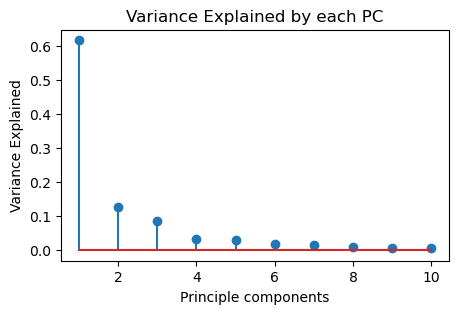

array([0.61706255, 0.12821388, 0.08557594, 0.03309336, 0.03050104,
       0.01833002, 0.01638928, 0.01072791, 0.00769639, 0.00685547])

In [52]:
####### NOTE: Only run this when building PC subspaces not when projecting test data into prexisting PC subspaces #######
%matplotlib inline

n_components = 10 # number of output PCs to reduce
use_single_trial = False
# Perform PCA
# Keep a copy of the neural data used for building PCA 
activity_filtered_training = activity_filtered.copy()
# Construct PCA input data
if use_single_trial:
    pca_train_input = copy.deepcopy(activity_filtered_singletrial).reshape(-1, N)
else:
    pca_train_input = copy.deepcopy(activity_filtered).reshape(-1, N)
PCA_model = ndp.apply_pca(pca_train_input,n_components,plot=True)

pc_axes = PCA_model.components_
loadings = PCA_model.components_.T * np.sqrt(PCA_model.explained_variance_)

save_results = False
if save_results:
    if len(TrialTags) == periswitch_range.shape[0]:
        np.savez(results_dir+file_name+f"_PCA_axes+loadings_{alignment}{aligned_interval[0]}to{aligned_interval[1]}s_Switch{periswitch_range[0]}to{periswitch_range[-1]}.npz",pc_axes=pc_axes,loadings=loadings,allow_pickle=True)
    if len(TrialTags) == periswitch_range.shape[0]*2:
        np.savez(results_dir+file_name+f"_PCA_axes+loadings_{alignment}{aligned_interval[0]}to{aligned_interval[1]}s_SwitchID+ActionConditions.npz",pc_axes=pc_axes,loadings=loadings,allow_pickle=True)
    if len(TrialTags) == periswitch_range.shape[0]*3:
        np.savez(results_dir+file_name+f"_PCA_axes+loadings_{alignment}{aligned_interval[0]}to{aligned_interval[1]}s_SwitchID+StartPatchConditions.npz",pc_axes=pc_axes,loadings=loadings,allow_pickle=True)

PCA_model.explained_variance_ratio_

In [63]:
# Project test neural data onto the PC axes.
C = activity_filtered.shape[1] # Number of conditions
isolate_switch_trials = False # Test data use separately-defined durations for stay and switch trials
if isolate_switch_trials:
    pca_test_input = copy.deepcopy(activity_filtered[:,:C-1,:]).reshape(-1, N) # Pre-switch conditions
    X_stay = PCA_model.transform(pca_test_input)
    Xnew_stay = np.reshape(X_stay, [-1, C-1, n_components])
    pca_test_input = copy.deepcopy(activity_filtered[:,C-1,:]).reshape(-1, N) # Switch condition
    X_switch = PCA_model.transform(pca_test_input)
    Xnew_switch = np.reshape(X_switch, [-1, 1, n_components])
    Xnew = np.empty((Xnew_switch.shape[0],C,n_components)) * np.nan
    Xnew[:Xnew_stay.shape[0],:C-1,:] = Xnew_stay
    Xnew[:Xnew_switch.shape[0],C-1:C,:] = Xnew_switch
else:
    ###### project neural data without separating stay and switch trials:
    pca_test_input = copy.deepcopy(activity_filtered).reshape(-1, N)
    X = PCA_model.transform(pca_test_input)
    Xnew = np.reshape(X, [-1, C, n_components])

#### If we want to plot condition-averaged neural trajectories along each individual PC for different peri-switch conditions

In [64]:
# Create a colormap for plotting
if 'Reward' in TrialTags[0]:
    ####### For plotting rewarded vs. unrewarded trials
    colormap = np.concatenate((np.flipud(cm.Reds(np.linspace(0,1,sum('Rewarded' in s for s in TrialTags)+5))[5:]),\
                               np.flipud(cm.Blues(np.linspace(0,1,peri_switch_ids.shape[0]+5))[5:])),axis=0)
    assert colormap.shape[0] == Xnew.shape[1]
    ####### When there's no rewarded switch-2 and switch-1 trials:
    # colormap = np.concatenate((cm.Reds(np.linspace(0,1,7)[1:]),\ # Rewarded trials
    #                            cm.Blues(np.linspace(0,1,peri_switch_ids.shape[0]+1)[1:])),axis=0) # Unrewarded trials

else:
    if Xnew.shape[1] == peri_switch_ids.shape[0]:
        colormap = cm.viridis(np.linspace(0,1,peri_switch_ids.shape[0]))
    else:
        if Xnew.shape[1] == peri_switch_ids.shape[0]*2:
            ####### left/right turns:
            colormap = np.concatenate((np.flipud(cm.Purples(np.linspace(0,1,peri_switch_ids.shape[0]+5))[5:]),\
                                       np.flipud(cm.Greens(np.linspace(0,1,peri_switch_ids.shape[0]+5))[5:])),axis=0)
        else:
            if Xnew.shape[1] == peri_switch_ids.shape[0]*3:
                ##### Three patches:
                # colormap = np.concatenate((np.flipud(cm.Reds(np.linspace(0,1,peri_switch_ids.shape[0]+5))[5:]),\
                #                            np.flipud(cm.Blues(np.linspace(0,1,peri_switch_ids.shape[0]+5))[5:]),\
                #                            np.flipud(cm.Greens(np.linspace(0,1,peri_switch_ids.shape[0]+5))[5:])),axis=0)
                colormap = np.concatenate((cm.PiYG_r(np.linspace(0,1,peri_switch_ids.shape[0]*2+8))[np.concatenate((np.arange(0,peri_switch_ids.shape[0]),np.arange(peri_switch_ids.shape[0]*2+7,peri_switch_ids.shape[0]+7,-1))),:],\
                                           np.flipud(cm.Blues(np.linspace(0,1,peri_switch_ids.shape[0]+5))[5:])),axis=0)
          
            else:
                if Xnew.shape[1] == peri_switch_ids.shape[0]*6:
                    # 6 leaves:
                    colormap = np.concatenate((cm.PiYG_r(np.linspace(0,1,peri_switch_ids.shape[0]*2+8))[np.concatenate((np.arange(0,peri_switch_ids.shape[0]),np.arange(peri_switch_ids.shape[0]*2+7,peri_switch_ids.shape[0]+7,-1))),:],\
                                               cm.RdGy_r(np.linspace(0,1,peri_switch_ids.shape[0]*2+8))[np.concatenate((np.arange(0,peri_switch_ids.shape[0]),np.arange(peri_switch_ids.shape[0]*2+7,peri_switch_ids.shape[0]+7,-1))),:],\
                                               np.flipud(cm.Blues(np.linspace(0,1,peri_switch_ids.shape[0]+5))[5:]),\
                                               np.flipud(cm.Purples(np.linspace(0,1,peri_switch_ids.shape[0]+5))[5:])),axis=0)


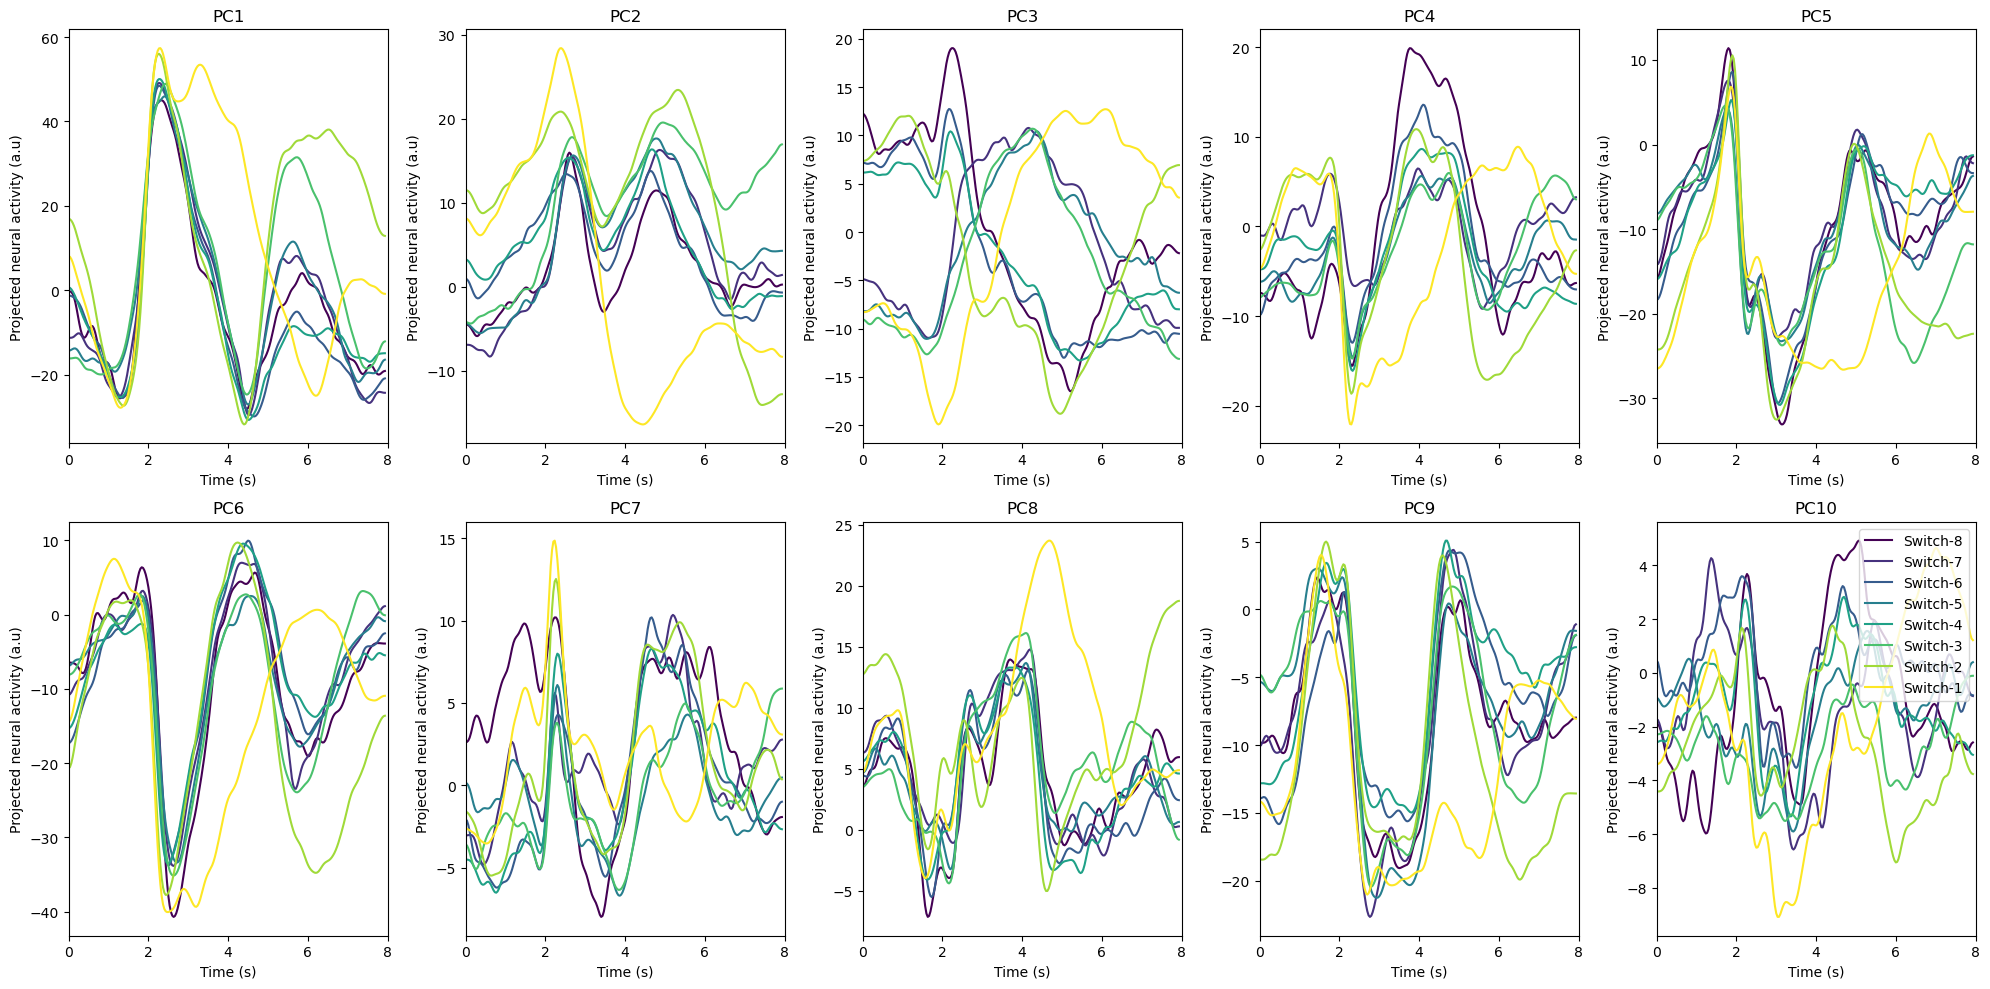

In [65]:
mpl.rcParams.update(mpl.rcParamsDefault)
%matplotlib inline
plt.close('all') 

time_to_plot = [0,aligned_interval[1]-aligned_interval[0]]#in seconds
plot_every_n_cond = 1
start_cond = 0
order_by_value = False
save_plot = False

plt.figure(figsize=(20, 10))  # Increase the height to accommodate two rows
C_plot = Xnew.shape[1]
   
for j in range(n_components):
    for target in np.arange(start_cond,C_plot,plot_every_n_cond):
        plt.subplot(2, int(n_components/2), j+1)
        if order_by_value:
            plt.plot(np.arange(0,Xnew.shape[0]/myData.BinsPerSec,1/myData.BinsPerSec), Xnew[:, target, j], color=colormap[color_by_value[target],:])
        else:
            plt.plot(np.arange(0,Xnew.shape[0]/myData.BinsPerSec,1/myData.BinsPerSec), Xnew[:, target, j], color=colormap[target,:])
        plt.title(f'PC{j+1}')
        plt.xlim(time_to_plot)
        plt.xlabel("Time (s)")
        plt.ylabel("Projected neural activity (a.u)")

if Xnew.shape[1] == peri_switch_ids.shape[0]:
    plt.legend([f'switch{i}'for i in peri_switch_ids[np.arange(start_cond,C_plot,plot_every_n_cond)]],loc='upper right')
plt.legend(TrialTags,loc='upper right')
plt.tight_layout()

if save_plot:
    if len(TrialTags) == peri_switch_ids.shape[0]:
        figname = f'{file_name}_regularPCA_periswitch_{aligned_interval[0]}to{aligned_interval[1]}s_PCs1-{n_components}_Switch{peri_switch_ids[0]}to{peri_switch_ids[-1]}.pdf'
    if len(TrialTags) == peri_switch_ids.shape[0]*2:
        figname = f'{file_name}_regularPCA_periswitch_{aligned_interval[0]}to{aligned_interval[1]}s_PCs1-{n_components}_TrialID+ActionConditions.pdf'
    if len(TrialTags) == peri_switch_ids.shape[0]*3:
        figname = f'{file_name}_regularPCA_periswitch_{aligned_interval[0]}to{aligned_interval[1]}s_PCs1-{n_components}_TrialID+PatchConditions.pdf'
    if len(TrialTags) == peri_switch_ids.shape[0]*6:
        figname = f'{file_name}_regularPCA_periswitch_{aligned_interval[0]}to{aligned_interval[1]}s_PCs1-{n_components}_TrialID+JourneyConditions.pdf'
    if order_by_value:
        figname = figname[:-4]+'_ColoredByValue.pdf'
    if use_selected_sessions:
        figname = figname[:-4]+f"_r{''.join(str(int(n)) for n in epoch_selected/2)}_300msKernel.pdf"
    if from_best_patch:
        figname = figname[:-4]+"_bestpatch.pdf"
    plt.savefig(fig_dir+figname, transparent=True)


#### If we want to plot 3D neural trajectories across different conditions

In [ ]:
mpl.rcParams.update(mpl.rcParamsDefault)
%matplotlib inline
# %matplotlib widget

fig = plt.figure(figsize=plt.figaspect(.5))
# fig = plt.figure(figsize=(8,4))
# pc_plot = [1,2,4]
pc_plot = [1,2,3]
# pc_plot = [1,5,2]
marker_time = int(np.floor((0-aligned_interval[0])*myData.BinsPerSec))
# marker_time = int(np.floor(0*myData.BinsPerSec))
plot_every_n_cond = 2
start_cond = 0
save_plot = False
plot_value_axis = False
order_by_value = False

# First plot conditions of one duration
if 'Rewarded' in TrialTags[0]:
    if TrialTags.shape[0]%2 == 0:
        if plot_every_n_cond == 2:
            plot_conditions1 = np.array([1,3,5,7]) # Rewarded odd trials
            # plot_conditions1 = np.array([0,2,4,6]) # Rewarded even trials
        else:
            plot_conditions1 = np.arange(start_cond,sum('Rewarded' in s for s in TrialTags),plot_every_n_cond) # Rewarded trials        
    else:
        plot_conditions1 = np.concatenate((np.arange(start_cond,sum('Rewarded' in s for s in TrialTags),plot_every_n_cond),[sum('Rewarded' in s for s in TrialTags)-1])) # Rewarded trials when there's no rewarded switch - 1
    plot_interval1 = [-5,0] # Rewarded trials outcome period
else:
    plot_conditions1 = np.arange(0,peri_switch_ids.shape[0]-1) # All stay trials for progression conditions
    # plot_conditions1 = [1,3,5,17,19,21] # Selected stay trials in patches AC
    # plot_conditions1 = [0,1,2,3,4,5,6,16,17,18,19,20,21,22] # All stay trials in patches AC
    # plot_conditions1 = [1,3,5,9,11,13] # Selected stay trials in patches AB or journeys 12
    # plot_conditions1 = [0,1,2,3,4,5,6,8,9,10,11,12,13] # All stay trials in patches AB or journeys 12
    # plot_conditions1 = [0,2,4,6,8,10,12,14,16,18,20,22] # Selected stay trials in patches ABC
    # plot_conditions1 = [0,1,2,3,4,5,6,8,9,10,11,12,13,14,16,17,18,19,20,21,22] # All stay trials in stems ABC
    # plot_conditions1 = [17,19,21,25,27,29] # Selected stay trials in journeys 34
    # plot_conditions1 = [16,17,18,19,20,21,22,24,25,26,27,28,29,30] # Stay trials in journeys 34
    # plot_conditions1 = [32,33,34,35,36,37,38,40,41,42,43,44,45,46] # Stay trials in journeys 56
    # plot_conditions1 = [17,19,21,25,27,29,33,35,37,41,43,45] # Selected stay trials in journeys 3456
    # plot_conditions1 = [2,5,6,11,13,14] # Selected stay trials separated by turns
    # plot_conditions1 = [0,1,2,3,4,5,6,8,9,10,11,12,13,14] # All stay trials separated by turns
    # plot_conditions1 = [1,6,7] # Selected stay trials for goal paorgress conditions

    plot_interval1 = [-0.8,round(myData.TrialDataTable[myData.TrialDataTable.IsSwitch==False].DurationRun.median(),1)]

print(f'plot duration of first condition is {plot_interval1}')

time_to_plot = [int(np.floor((plot_interval1[0]-aligned_interval[0])*myData.BinsPerSec)),int(np.ceil((plot_interval1[1]-aligned_interval[0])*myData.BinsPerSec))+1] #seconds
ax1 = fig.add_subplot(121)
for target in plot_conditions1:
    if order_by_value:
        ax1.plot(Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[0]-1], Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[1]-1], \
                 color=colormap[color_by_value[target],:])
        ax1.scatter(Xnew[marker_time, target, pc_plot[0]-1], Xnew[marker_time, target, pc_plot[1]-1], \
                    color=colormap[color_by_value[target],:], marker='o', label='_nolegend_')
    else:
        ax1.plot(Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[0]-1], Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[1]-1], color=colormap[target,:])
        ax1.scatter(Xnew[marker_time, target, pc_plot[0]-1], Xnew[marker_time, target, pc_plot[1]-1], color=colormap[target,:], marker='o', label='_nolegend_')
ax2 = fig.add_subplot(122, projection='3d')
for target in plot_conditions1:
    if order_by_value:
        ax2.plot3D(Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[0]-1], Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[1]-1], Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[2]-1], \
                   color=colormap[color_by_value[target],:], linewidth=0.8)
        ax2.scatter(Xnew[marker_time, target, pc_plot[0]-1], Xnew[marker_time, target, pc_plot[1]-1], Xnew[marker_time, target, pc_plot[2]-1], \
                    color=colormap[color_by_value[target],:], label='_nolegend_')
    else:
        ax2.plot3D(Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[0]-1], Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[1]-1], Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[2]-1], color=colormap[target,:], linewidth=0.8)
        ax2.scatter(Xnew[marker_time, target, pc_plot[0]-1], Xnew[marker_time, target, pc_plot[1]-1], Xnew[marker_time, target, pc_plot[2]-1], color=colormap[target,:], label='_nolegend_')

# Second plot condition of a different duration
if 'Rewarded' in TrialTags[0]:
    plot_conditions2 = np.arange(sum('Rewarded' in s for s in TrialTags)+1,C_plot,plot_every_n_cond)# Unrewarded odd trials
    # plot_conditions2 = np.arange(sum('Rewarded' in s for s in TrialTags),C_plot,plot_every_n_cond)# Unrewarded even trials
    plot_interval2 = [-0.8,0] # Unrewarded trials outcome period
else:
    plot_conditions2 = [peri_switch_ids.shape[0]-1] # Switch trial for progression bins
    # plot_conditions2 = [7,23] # Switch trials in patches AC
    # plot_conditions2 = [7,15] # Switch trials in patches AB, or switch left turn vs. right turn, or journeys 12; aligned to trialend
    # plot_conditions2 = [8,17] # Switch trials in patches AB, or switch left turn vs. right turn, or journeys 12; aligned to trialstart
    # plot_conditions2 = [23,31] # Switch trials journey 34
    # plot_conditions2 = [39,47] # Switch trials journey 56
    # plot_conditions2 = [23,31,39,47] # Switch trials journey 3456

    plot_interval2 = [-0.8,round(myData.TrialDataTable[myData.TrialDataTable.IsSwitch].DurationRun.median(),1)]

print(f'plot duration of second condition is {plot_interval2}')

time_to_plot = [int(np.floor((plot_interval2[0]-aligned_interval[0])*myData.BinsPerSec)),int(np.ceil((plot_interval2[1]-aligned_interval[0])*myData.BinsPerSec))+1] #seconds        
for target in plot_conditions2:
    ax1.plot(Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[0]-1], Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[1]-1], color=colormap[target,:])
    ax1.scatter(Xnew[marker_time, target, pc_plot[0]-1], Xnew[marker_time, target, pc_plot[1]-1], color=colormap[target,:], marker='o', label='_nolegend_')                
ax1.set_xlabel(f'PC {pc_plot[0]}')
ax1.set_ylabel(f'PC {pc_plot[1]}')

for target in plot_conditions2:
    if order_by_value:
        ax2.plot3D(Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[0]-1], Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[1]-1], Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[2]-1], \
                   color=colormap[color_by_value[target],:], linewidth=0.8)
        ax2.scatter(Xnew[marker_time, target, pc_plot[0]-1], Xnew[marker_time, target, pc_plot[1]-1], Xnew[marker_time, target, pc_plot[2]-1], \
                    color=colormap[color_by_value[target],:], label='_nolegend_')
    else:
        ax2.plot3D(Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[0]-1], Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[1]-1], Xnew[time_to_plot[0]:time_to_plot[1], target, pc_plot[2]-1], color=colormap[target,:], linewidth=0.8)
        ax2.scatter(Xnew[marker_time, target, pc_plot[0]-1], Xnew[marker_time, target, pc_plot[1]-1], Xnew[marker_time, target, pc_plot[2]-1], color=colormap[target,:], label='_nolegend_')
        # ax2.scatter(Xnew[int(np.floor((3-aligned_interval[0])*myData.BinsPerSec)), target, pc_plot[0]-1], Xnew[int(np.floor((3-aligned_interval[0])*myData.BinsPerSec)), target, pc_plot[1]-1], Xnew[int(np.floor((3-aligned_interval[0])*myData.BinsPerSec)), target, pc_plot[2]-1], color=colormap[target,:], label='_nolegend_')

if plot_value_axis:
    scalar = 500
    arrow_colors = ['k','r']
    if Xnew.shape[1] == peri_switch_ids.shape[0]:
        projection = np.dot(pc_axes, beta_coeff_pause[-1,:]) # Projection is the value-decoding axis projected into the PC subspace.
        # projection = np.dot(pc_axes, beta_coeff_run[0,:]) # Projection is the value-decoding axis projected into the PC subspace.
        scaled_projection = projection * scalar
        ax2.quiver(0, 0, 0, scaled_projection[pc_plot[0]-1], scaled_projection[pc_plot[1]-1], scaled_projection[pc_plot[2]-1], color=arrow_colors[0], linewidth=2, length=0.8)
    if Xnew.shape[1] == peri_switch_ids.shape[0] * 2:
        projection = np.vstack((np.dot(pc_axes, beta_value[-7,:]),np.dot(pc_axes, beta_value[-15,:]))) 
        scaled_projection = projection * scalar
        for i in range(scaled_projection.shape[0]):
            ax2.quiver(0, 0, 0, scaled_projection[i,pc_plot[0]-1], scaled_projection[i,pc_plot[1]-1], scaled_projection[i,pc_plot[2]-1], color=arrow_colors[i], linewidth=2, length=0.8)
    print([scaled_projection[pc_plot[0]-1], scaled_projection[pc_plot[1]-1], scaled_projection[pc_plot[2]-1]])

ax2.set_xlabel(f'PC {pc_plot[0]}')
ax2.set_ylabel(f'PC {pc_plot[1]}')
ax2.set_zlabel(f'PC {pc_plot[2]}')
elev = 72
azim = 70
roll = -110
ax2.view_init(elev=elev, azim=azim, roll=roll)

legends = np.concatenate((np.array(TrialTags)[plot_conditions1],np.array(TrialTags)[plot_conditions2]))
if legends.shape[0] < 10:
    ax1.legend(legends,loc='upper right')
    # ax1.legend(TrialTags[np.arange(start_cond,C_plot,plot_every_n_cond)],bbox_to_anchor=(1.5,1))

if save_plot:
    if 'Rewarded' in TrialTags[0]:
        figname = f'{file_name}_regularPCA_periswitch_{plot_interval1[0]}to{plot_interval1[1]}sAnd{plot_interval2[0]}to{plot_interval2[1]}s_PC{pc_plot[0]}{pc_plot[1]}{pc_plot[2]}_RewardOutcomeConditions_Elev{elev}Azim{azim}Roll{roll}.pdf'        
    else:
        if len(TrialTags) == peri_switch_ids.shape[0]:
            figname = f'{file_name}_regularPCA_periswitch_{plot_interval1[0]}to{plot_interval1[1]}sAnd{plot_interval2[0]}to{plot_interval2[1]}s_PC{pc_plot[0]}{pc_plot[1]}{pc_plot[2]}_Switch{peri_switch_ids[0]}to{peri_switch_ids[-1]}_Elev{elev}Azim{azim}Roll{roll}.pdf'
        if len(TrialTags) == peri_switch_ids.shape[0]*2:
            figname = f'{file_name}_regularPCA_periswitch_{plot_interval1[0]}to{plot_interval1[1]}sAnd{plot_interval2[0]}to{plot_interval2[1]}s_PC{pc_plot[0]}{pc_plot[1]}{pc_plot[2]}_TrialID+ActionConditions_Elev{elev}Azim{azim}Roll{roll}.pdf'
        if len(TrialTags) == peri_switch_ids.shape[0]*3:
            figname = f'{file_name}_regularPCA_periswitch_{plot_interval[0]}to{plot_interval[1]}s_PC{pc_plot[0]}{pc_plot[1]}{pc_plot[2]}_TrialID+StemConditions_Elev{elev}Azim{azim}Roll{roll}.pdf'
    
    if plot_every_n_cond != 1:
        if start_cond == 0:
            figname = figname[:-4]+"_EvenTrial.pdf"
        else:
            figname = figname[:-4]+"_OddTrial.pdf"
    if order_by_value:
        figname = figname[:-4]+'_ColoredByValue.pdf'
    if plot_value_axis:
        figname = figname[:-4]+'_WithValueAxis.pdf'
    if use_selected_sessions:
        figname = figname[:-4]+f"_r{''.join(str(int(n)) for n in epoch_selected/2)}.pdf"
    if from_best_patch:
        figname = figname[:-4]+"_bestpatch.pdf"
    plt.rc('text', usetex=True)
    plt.savefig(fig_dir+figname, transparent=True)
    

# Adjust spacing between subplots
plt.tight_layout();

plot duration of first condition is [-0.8, 2.5]
plot duration of second condition is [-0.8, 4.2]
